# Loan Risk Analyzer — Análise Exploratória e Pré-processamento

**Projeto Integrador — Engenharia de Software para IA e Frameworks Profundos**


## 1. Configuração do Ambiente

In [2]:
import os
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import numpy as np

import matplotlib.pyplot as plt
project_root = Path.cwd().resolve()
if not (project_root / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

SEED = 20

## 2. Carregamento do Dataset

In [3]:
dataset = pd.read_csv( str(project_root / "data" / "loan_data.csv") )
dataset.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 4. Visualização Gráfica do Dataset
Gráficos para entendimento da relação entre as variáveis

### Distribuição das classes

In [7]:
print('Shape: ', dataset.shape, '\n')
print( 'Distribuição das classes:\n', dataset['loan_status'].value_counts().to_string() )

Shape:  (45000, 14) 

Distribuição das classes:
 loan_status
0    35000
1    10000


### Relação entre renda x Valor do empréstimo x Status

<Axes: xlabel='loan_amnt', ylabel='person_income'>

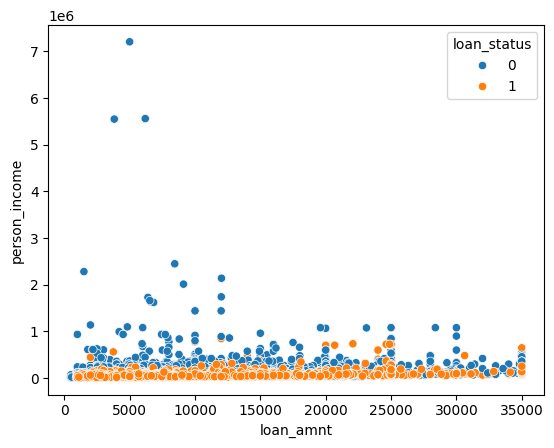

In [8]:
sns.scatterplot(x="loan_amnt", y="person_income", hue="loan_status", data=dataset)

### Taxa de default por variável categórica

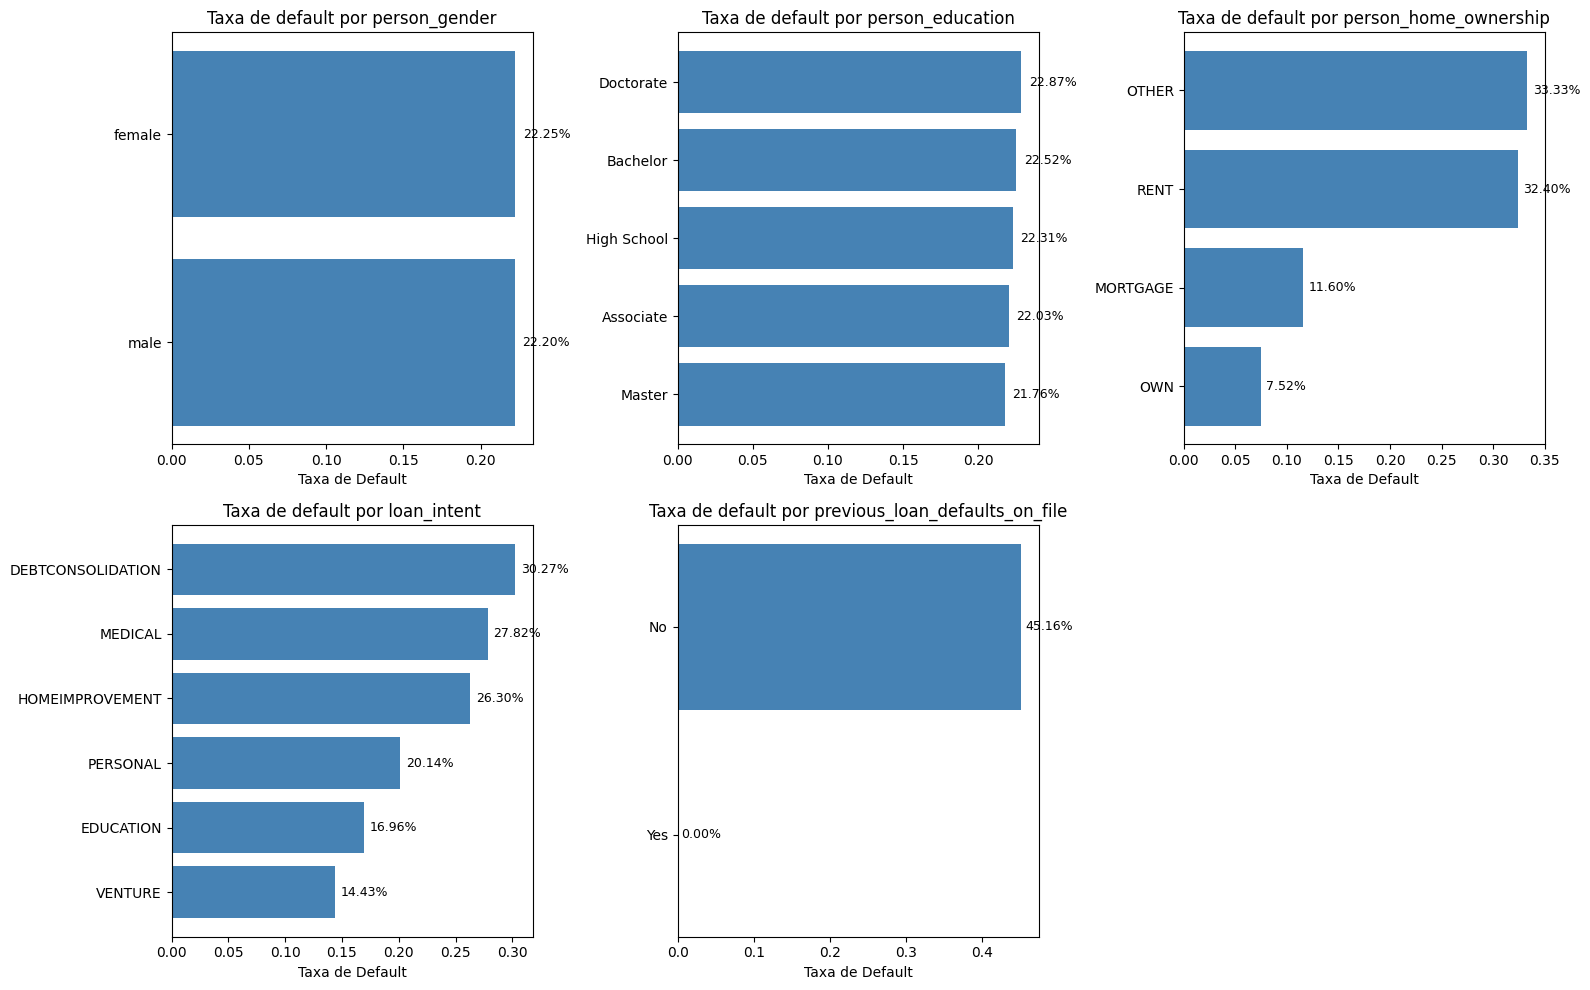

In [10]:
categorical_cols = ["person_gender", "person_education", "person_home_ownership",
                   "loan_intent", "previous_loan_defaults_on_file"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    default_rate = dataset.groupby(col)["loan_status"].mean().sort_values()
    axes[i].barh(default_rate.index.astype(str), default_rate.values, color="steelblue")
    axes[i].set_title(f"Taxa de default por {col}")
    axes[i].set_xlabel("Taxa de Default")
    for j, v in enumerate(default_rate.values):
        axes[i].text(v + 0.005, j, f"{v:.2%}", va="center", fontsize=9)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

### Mapa de correlação entre variáveis numéricas

AttributeError: QuadMesh.set() got an unexpected keyword argument 'cbar_kgs'

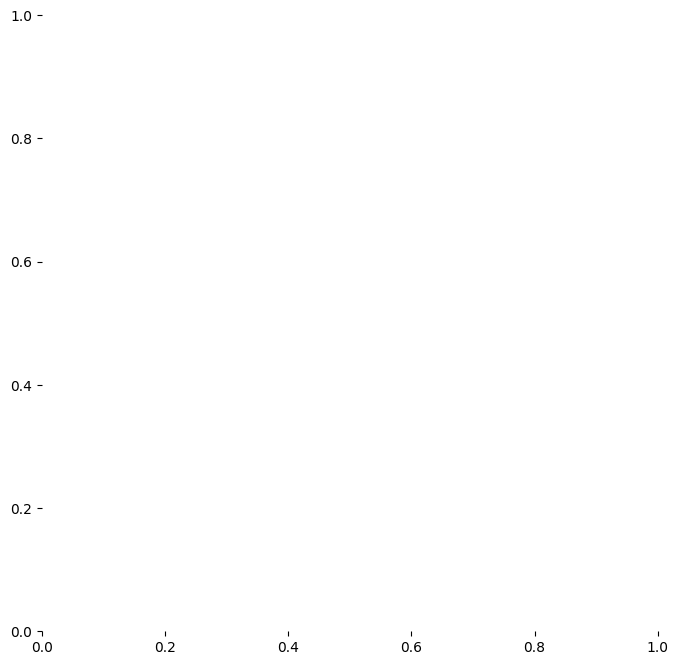

In [12]:
numeric_dataset = dataset.select_dtypes(include=["float64", "int64"])
corr_matrix = numeric_dataset.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5,
            cbar_kgs={"shrink": 0.8})
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

## 5. Pré-Processamento

In [13]:
EDUCATION_ORDER = {
    "High School": 0,
    "Associate": 1,
    "Bachelor": 2,
    "Master": 3,
    "Doctorate": 4,
}

CATEGORICAL_COLUMNS = [
    "person_gender",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file",
]

In [20]:
# Label encoding considerando a ordem natural das categorias
dataset["person_education"] = dataset["person_education"].map(EDUCATION_ORDER)

# One-hot encoding das categorias restantes
encoder = OneHotEncoder(sparse_output=False)
categorical_encoded = encoder.fit_transform(dataset[CATEGORICAL_COLUMNS])
# Extrai as features numéricas (todas as colunas exceto as categóricas) e converte para NumPy
numeric_array = dataset.drop(columns=CATEGORICAL_COLUMNS).to_numpy()

# Retorna a combinação das features numéricas com as categóricas codificadas
np.hstack([numeric_array, categorical_encoded])

array([[2.2000e+01,        nan, 7.1948e+04, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.1000e+01,        nan, 1.2282e+04, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00],
       [2.5000e+01,        nan, 1.2438e+04, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       ...,
       [3.3000e+01,        nan, 5.6942e+04, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.9000e+01,        nan, 3.3164e+04, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.4000e+01,        nan, 5.1609e+04, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00]], shape=(45000, 24))